[*********************100%***********************]  1 of 1 completed


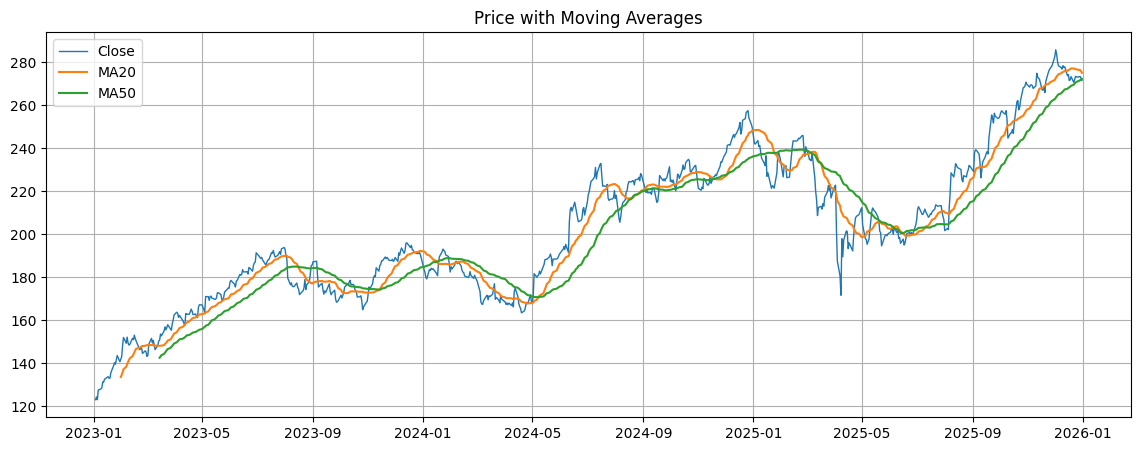

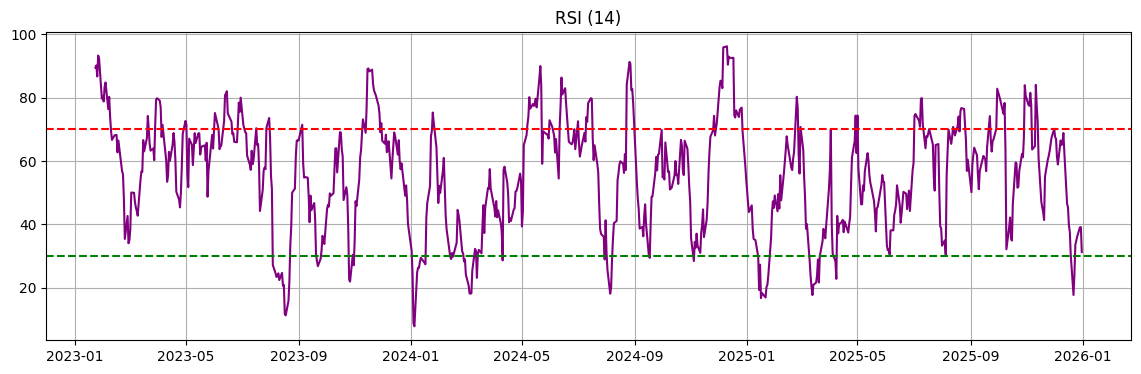

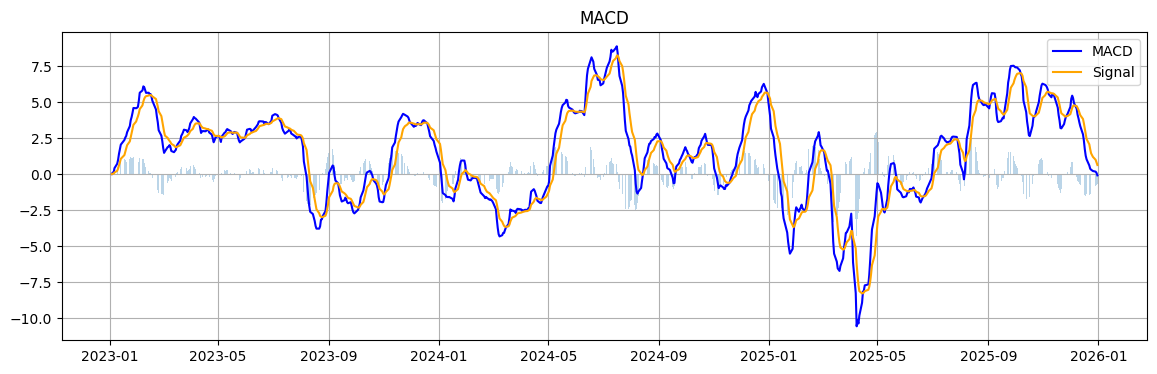

In [9]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# ---------------------------
# Load data
# ---------------------------
df = yf.download("AAPL", start="2023-01-01", end="2026-01-01")
df = df[['Close']].dropna()

# ---------------------------
# Moving Averages
# ---------------------------
df['MA20'] = df['Close'].rolling(20).mean()
df['MA50'] = df['Close'].rolling(50).mean()

# ---------------------------
# RSI (14)
# ---------------------------
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# ---------------------------
# MACD
# ---------------------------
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema12 - ema26
df['Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

# ===========================
# PLOT 1: Price + Moving Averages
# ===========================
plt.figure(figsize=(14, 5))
plt.plot(df['Close'], label='Close', linewidth=1)
plt.plot(df['MA20'], label='MA20')
plt.plot(df['MA50'], label='MA50')
plt.title("Price with Moving Averages")
plt.legend()
plt.grid()
plt.show()

# ===========================
# PLOT 2: RSI
# ===========================
plt.figure(figsize=(14, 4))
plt.plot(df['RSI'], color='purple')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title("RSI (14)")
plt.grid()
plt.show()

# ===========================
# PLOT 3: MACD
# ===========================
plt.figure(figsize=(14, 4))
plt.plot(df['MACD'], label='MACD', color='blue')
plt.plot(df['Signal'], label='Signal', color='orange')
plt.bar(df.index, df['MACD'] - df['Signal'], alpha=0.3)
plt.title("MACD")
plt.legend()
plt.grid()
plt.show()

Price + MA + Signal Markers (relationship view)

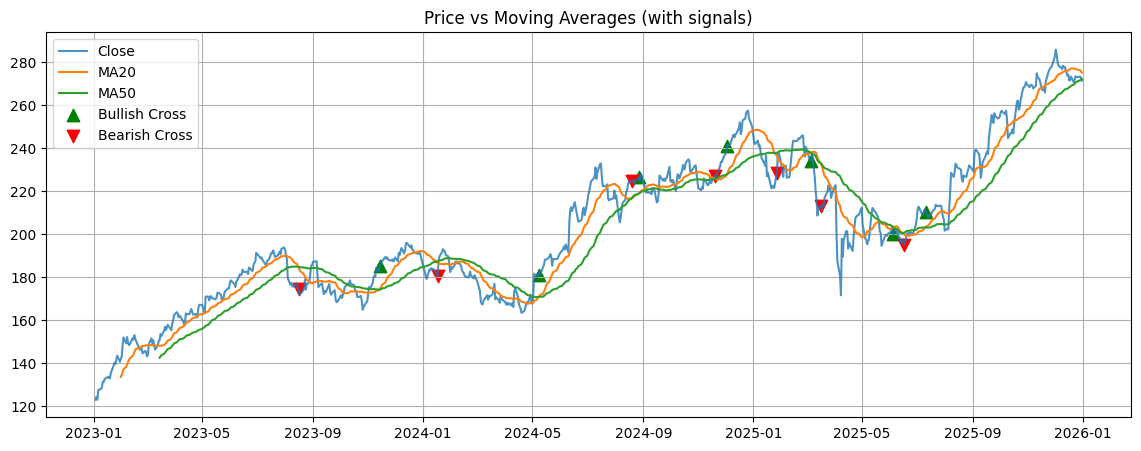

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Detect MA crossover signals
df['MA_cross_up'] = (df['MA20'] > df['MA50']) & (df['MA20'].shift(1) <= df['MA50'].shift(1))
df['MA_cross_down'] = (df['MA20'] < df['MA50']) & (df['MA20'].shift(1) >= df['MA50'].shift(1))

plt.figure(figsize=(14,5))
plt.plot(df['Close'], label='Close', alpha=0.8)
plt.plot(df['MA20'], label='MA20')
plt.plot(df['MA50'], label='MA50')

# Mark crossover points on price
plt.scatter(df.index[df['MA_cross_up']],
            df['Close'][df['MA_cross_up']],
            marker='^', color='green', label='Bullish Cross', s=80)

plt.scatter(df.index[df['MA_cross_down']],
            df['Close'][df['MA_cross_down']],
            marker='v', color='red', label='Bearish Cross', s=80)

plt.title("Price vs Moving Averages (with signals)")
plt.legend()
plt.grid()
plt.show()

RSI with price regime shading (overbought/oversold context)

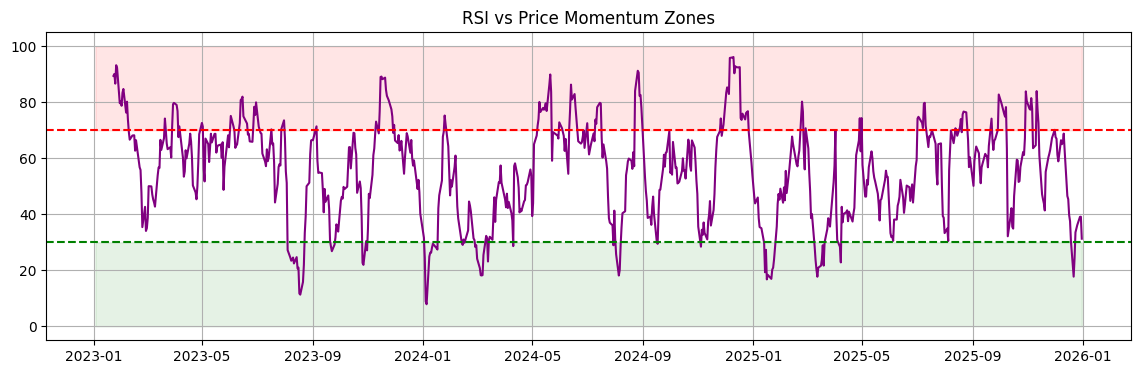

In [11]:
plt.figure(figsize=(14,4))
plt.plot(df['RSI'], color='purple')

plt.axhline(70, linestyle='--', color='red')
plt.axhline(30, linestyle='--', color='green')

# Highlight zones
plt.fill_between(df.index, 70, 100, color='red', alpha=0.1)
plt.fill_between(df.index, 0, 30, color='green', alpha=0.1)

plt.title("RSI vs Price Momentum Zones")
plt.grid()
plt.show()

MACD + price momentum alignment

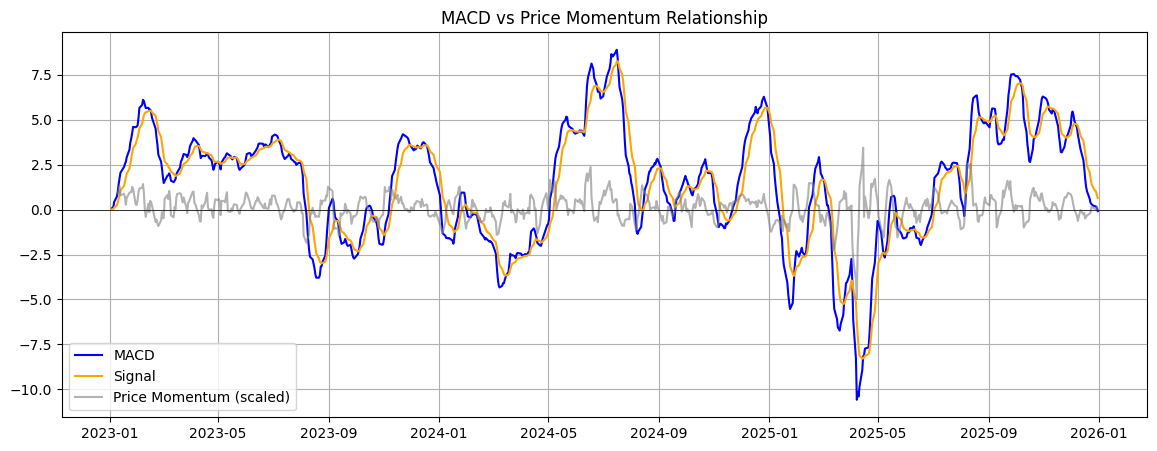

In [12]:
plt.figure(figsize=(14,5))

# Normalize price change for visual comparison
price_change = df['Close'].pct_change().rolling(5).mean()

plt.plot(df['MACD'], label='MACD', color='blue')
plt.plot(df['Signal'], label='Signal', color='orange')
plt.plot(price_change * 100, label='Price Momentum (scaled)', color='gray', alpha=0.6)

plt.axhline(0, color='black', linewidth=0.5)
plt.title("MACD vs Price Momentum Relationship")
plt.legend()
plt.grid()
plt.show()